In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pysam import AlignmentFile
import pysam
from scipy.signal import savgol_filter
from matplotlib import gridspec
from scipy.stats import gaussian_kde
from matplotlib.colors import ListedColormap
from tqdm import tqdm
import json

from cuban_lib.visualize import cuban, cuban_bnd
from cuban_lib.utils import compute_baseline_cov

plt.style.use('ggplot')

In [2]:
# Load repeat annotations
repeats = '/confidential/tGenVar/ref/hg38/annotation/hg38_repeatmasker.tsv'
repeat_df = pd.read_csv(repeats, sep='\t')

# DEL

(201, 234)
(201, 267)
(201, 285)
(201, 320)
(117, 199)
(84, 199)
(135, 199)
(170, 199)
(201, 243)
(201, 259)
(201, 281)
(201, 286)
(201, 317)
(139, 199)
(112, 199)
(96, 199)
(170, 199)
(134, 199)
(201, 399)
(201, 399)
(198, 399)
(201, 399)
(202, 399)
(201, 399)
(201, 399)
(201, 399)
(200, 399)
(200, 399)
(201, 399)
(200, 399)
(200, 399)
(0, 199)
(0, 199)
(0, 199)
(0, 199)
(19, 199)
(3, 199)
(0, 200)
(0, 200)
(0, 200)
(0, 200)
(0, 200)
(0, 200)
(0, 200)


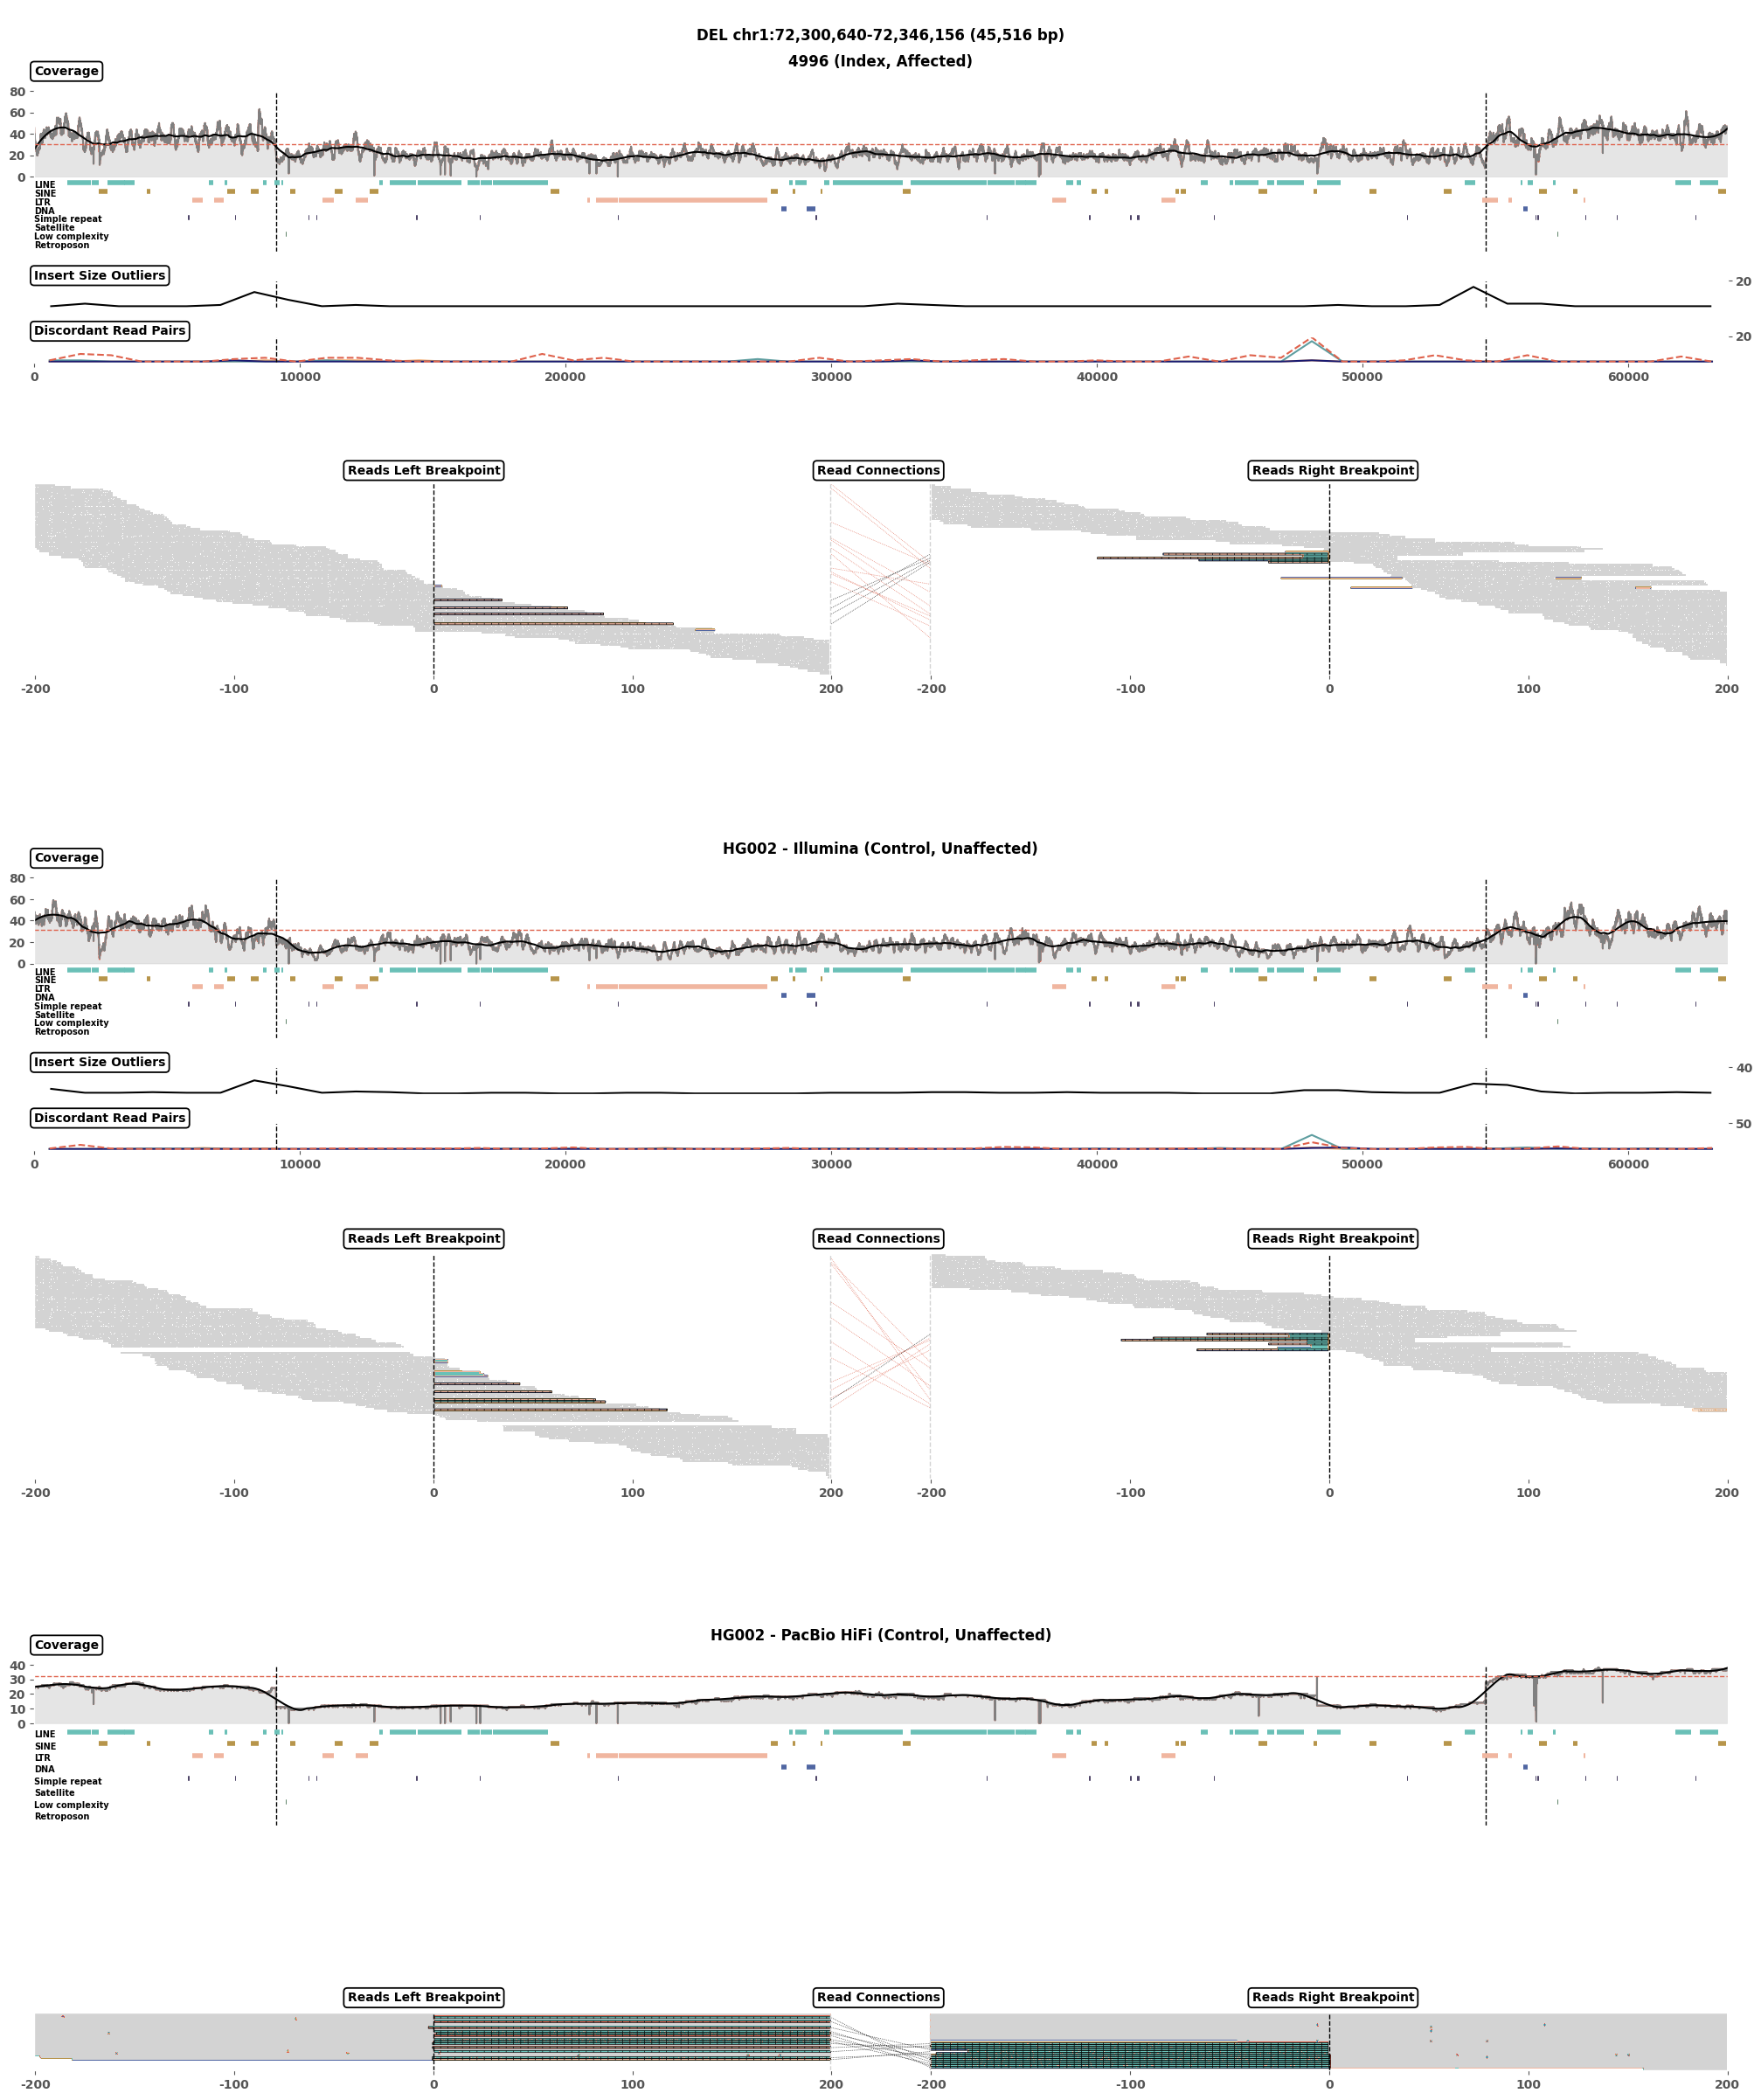

In [3]:
# Region
sv_type = 'DEL'
chrom = 'chr1'
start = 72300640
stop = 72346156
sv_len = stop - start

# Samples from cohort
cohort_samples = {'4996' : {'family_status' : 'index',
                              'disease_status' : 'affected',
                              'technology' : 'ill',
                              'bam_name' : f'/confidential/typo/cohorts/limb2/aligned_bam/4996/GRCh38.bwa_mem.pe.sorted.mdup.recal.bam',
                              'baseline_cov' : 30}}

# Load baseline coverage for control samples
with open('resources/baseline_cov_ill.json', 'r') as f:
    baseline_cov_ill = json.load(f)
with open('resources/baseline_cov_pb.json', 'r') as f:
    baseline_cov_pb = json.load(f)

# Samples from control
control_samples = {'HG002 - Illumina' : {'family_status' : 'control',
                                         'disease_status' : 'unaffected',
                                         'technology' : 'ill',
                                         'bam_name' : '/confidential/FamilyR13/DATA/10x/SCRIPT/tGenVar/svdb/data/raw/1kg/hg38/HG002/ill/bam/GRCh38.bwa_mem.pe.sorted.mdup.recal.bam',
                                         'baseline_cov' : baseline_cov_ill[chrom]},
                   'HG002 - PacBio HiFi' : {'family_status' : 'control',
                                            'disease_status' : 'unaffected',
                                            'technology' : 'pb',
                                            'bam_name' : '/confidential/FamilyR13/DATA/10x/SCRIPT/tGenVar/svdb/data/raw/1kg/hg38/HG002/pb_hifi/bam/HG002_GRCh38.haplotag.10x.bam',
                                            'baseline_cov' : baseline_cov_pb[chrom]}}

samples = {**cohort_samples, **control_samples}

cuban(samples, repeat_df, sv_type, chrom, start, stop, padding=1500, window=200, collapse_ins=False, sv_len=sv_len)

# DUP

(145, 153)
(276, 295)
(199, 255)
(195, 268)
(326, 345)
(181, 268)
(326, 331)
(190, 268)
(326, 340)
(178, 268)
(326, 328)
(186, 268)
(326, 336)
(176, 268)
(182, 300)
(218, 300)
(215, 300)
(206, 300)
(202, 300)
(200, 300)
(256, 318)
(328, 344)
(385, 399)
(298, 363)
(298, 363)
(16, 26)
(96, 159)
(96, 164)
(96, 169)
(96, 173)
(0, 19)
(96, 146)
(1, 20)
(112, 151)
(24, 28)
(96, 178)
(7, 36)
(96, 161)
(96, 196)
(52, 53)
(96, 202)
(96, 211)
(96, 214)
(153, 157)
(276, 300)
(276, 306)
(338, 399)
(326, 399)
(195, 268)
(326, 342)
(235, 268)
(326, 382)
(206, 268)
(326, 353)
(202, 268)
(326, 349)
(222, 300)
(290, 300)
(386, 399)
(255, 300)
(384, 399)
(286, 300)
(386, 399)
(193, 300)
(189, 300)
(302, 362)
(278, 363)
(36, 47)
(36, 88)
(60, 146)
(115, 176)
(87, 172)
(10, 26)
(115, 162)
(23, 26)
(115, 175)
(0, 26)
(115, 123)
(24, 28)
(96, 175)
(96, 186)
(119, 189)
(119, 189)
(115, 190)
(35, 53)
(96, 182)
(115, 225)
(0, 300)
(0, 300)
(0, 390)
(255, 399)
(256, 399)
(153, 399)
(153, 399)


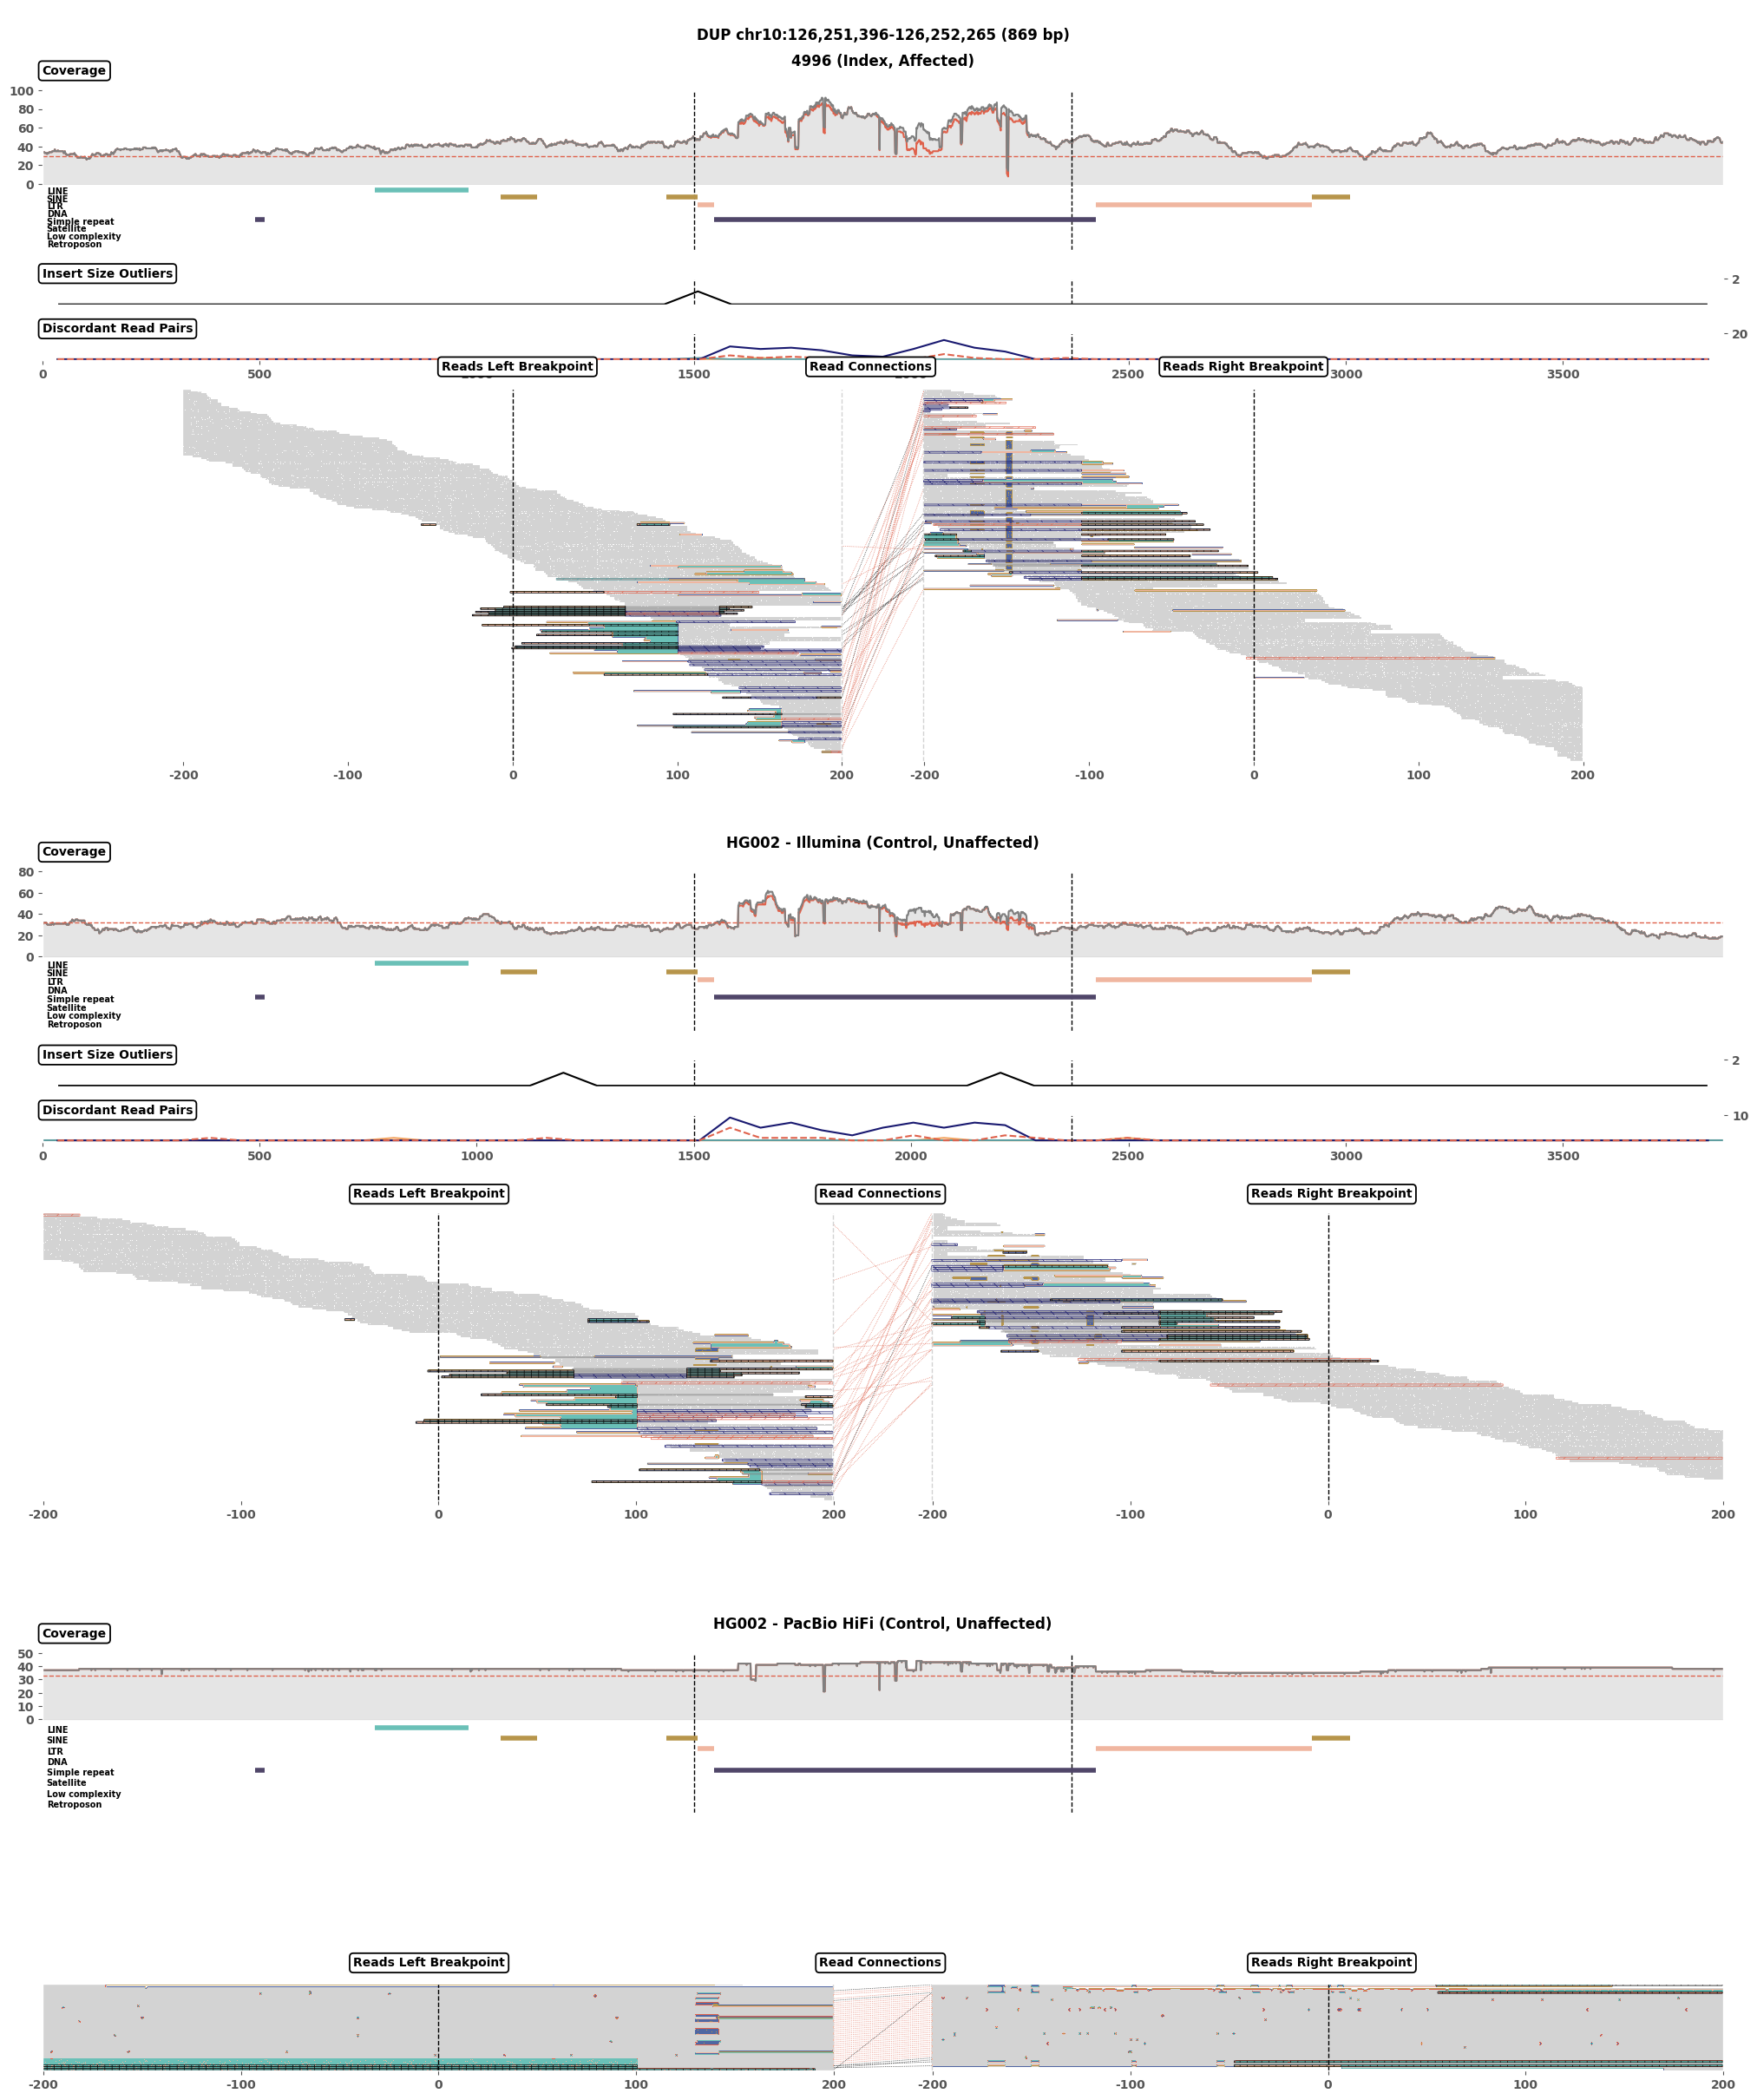

In [4]:
# Region
sv_type = 'DUP'
chrom = 'chr10'
start = 126251396
stop = 126252265
sv_len = stop - start

# Samples from cohort
cohort_samples = {'4996' : {'family_status' : 'index',
                              'disease_status' : 'affected',
                              'technology' : 'ill',
                              'bam_name' : f'/confidential/typo/cohorts/limb2/aligned_bam/4996/GRCh38.bwa_mem.pe.sorted.mdup.recal.bam',
                              'baseline_cov' : 30}}

# Load baseline coverage for control samples
with open('resources/baseline_cov_ill.json', 'r') as f:
    baseline_cov_ill = json.load(f)
with open('resources/baseline_cov_pb.json', 'r') as f:
    baseline_cov_pb = json.load(f)

# Samples from control
control_samples = {'HG002 - Illumina' : {'family_status' : 'control',
                                         'disease_status' : 'unaffected',
                                         'technology' : 'ill',
                                         'bam_name' : '/confidential/FamilyR13/DATA/10x/SCRIPT/tGenVar/svdb/data/raw/1kg/hg38/HG002/ill/bam/GRCh38.bwa_mem.pe.sorted.mdup.recal.bam',
                                         'baseline_cov' : baseline_cov_ill[chrom]},
                   'HG002 - PacBio HiFi' : {'family_status' : 'control',
                                            'disease_status' : 'unaffected',
                                            'technology' : 'pb',
                                            'bam_name' : '/confidential/FamilyR13/DATA/10x/SCRIPT/tGenVar/svdb/data/raw/1kg/hg38/HG002/pb_hifi/bam/HG002_GRCh38.haplotag.10x.bam',
                                            'baseline_cov' : baseline_cov_pb[chrom]}}

samples = {**cohort_samples, **control_samples}

cuban(samples, repeat_df, sv_type, chrom, start, stop, padding=1500, window=200, collapse_ins=False, sv_len=sv_len)

# INS

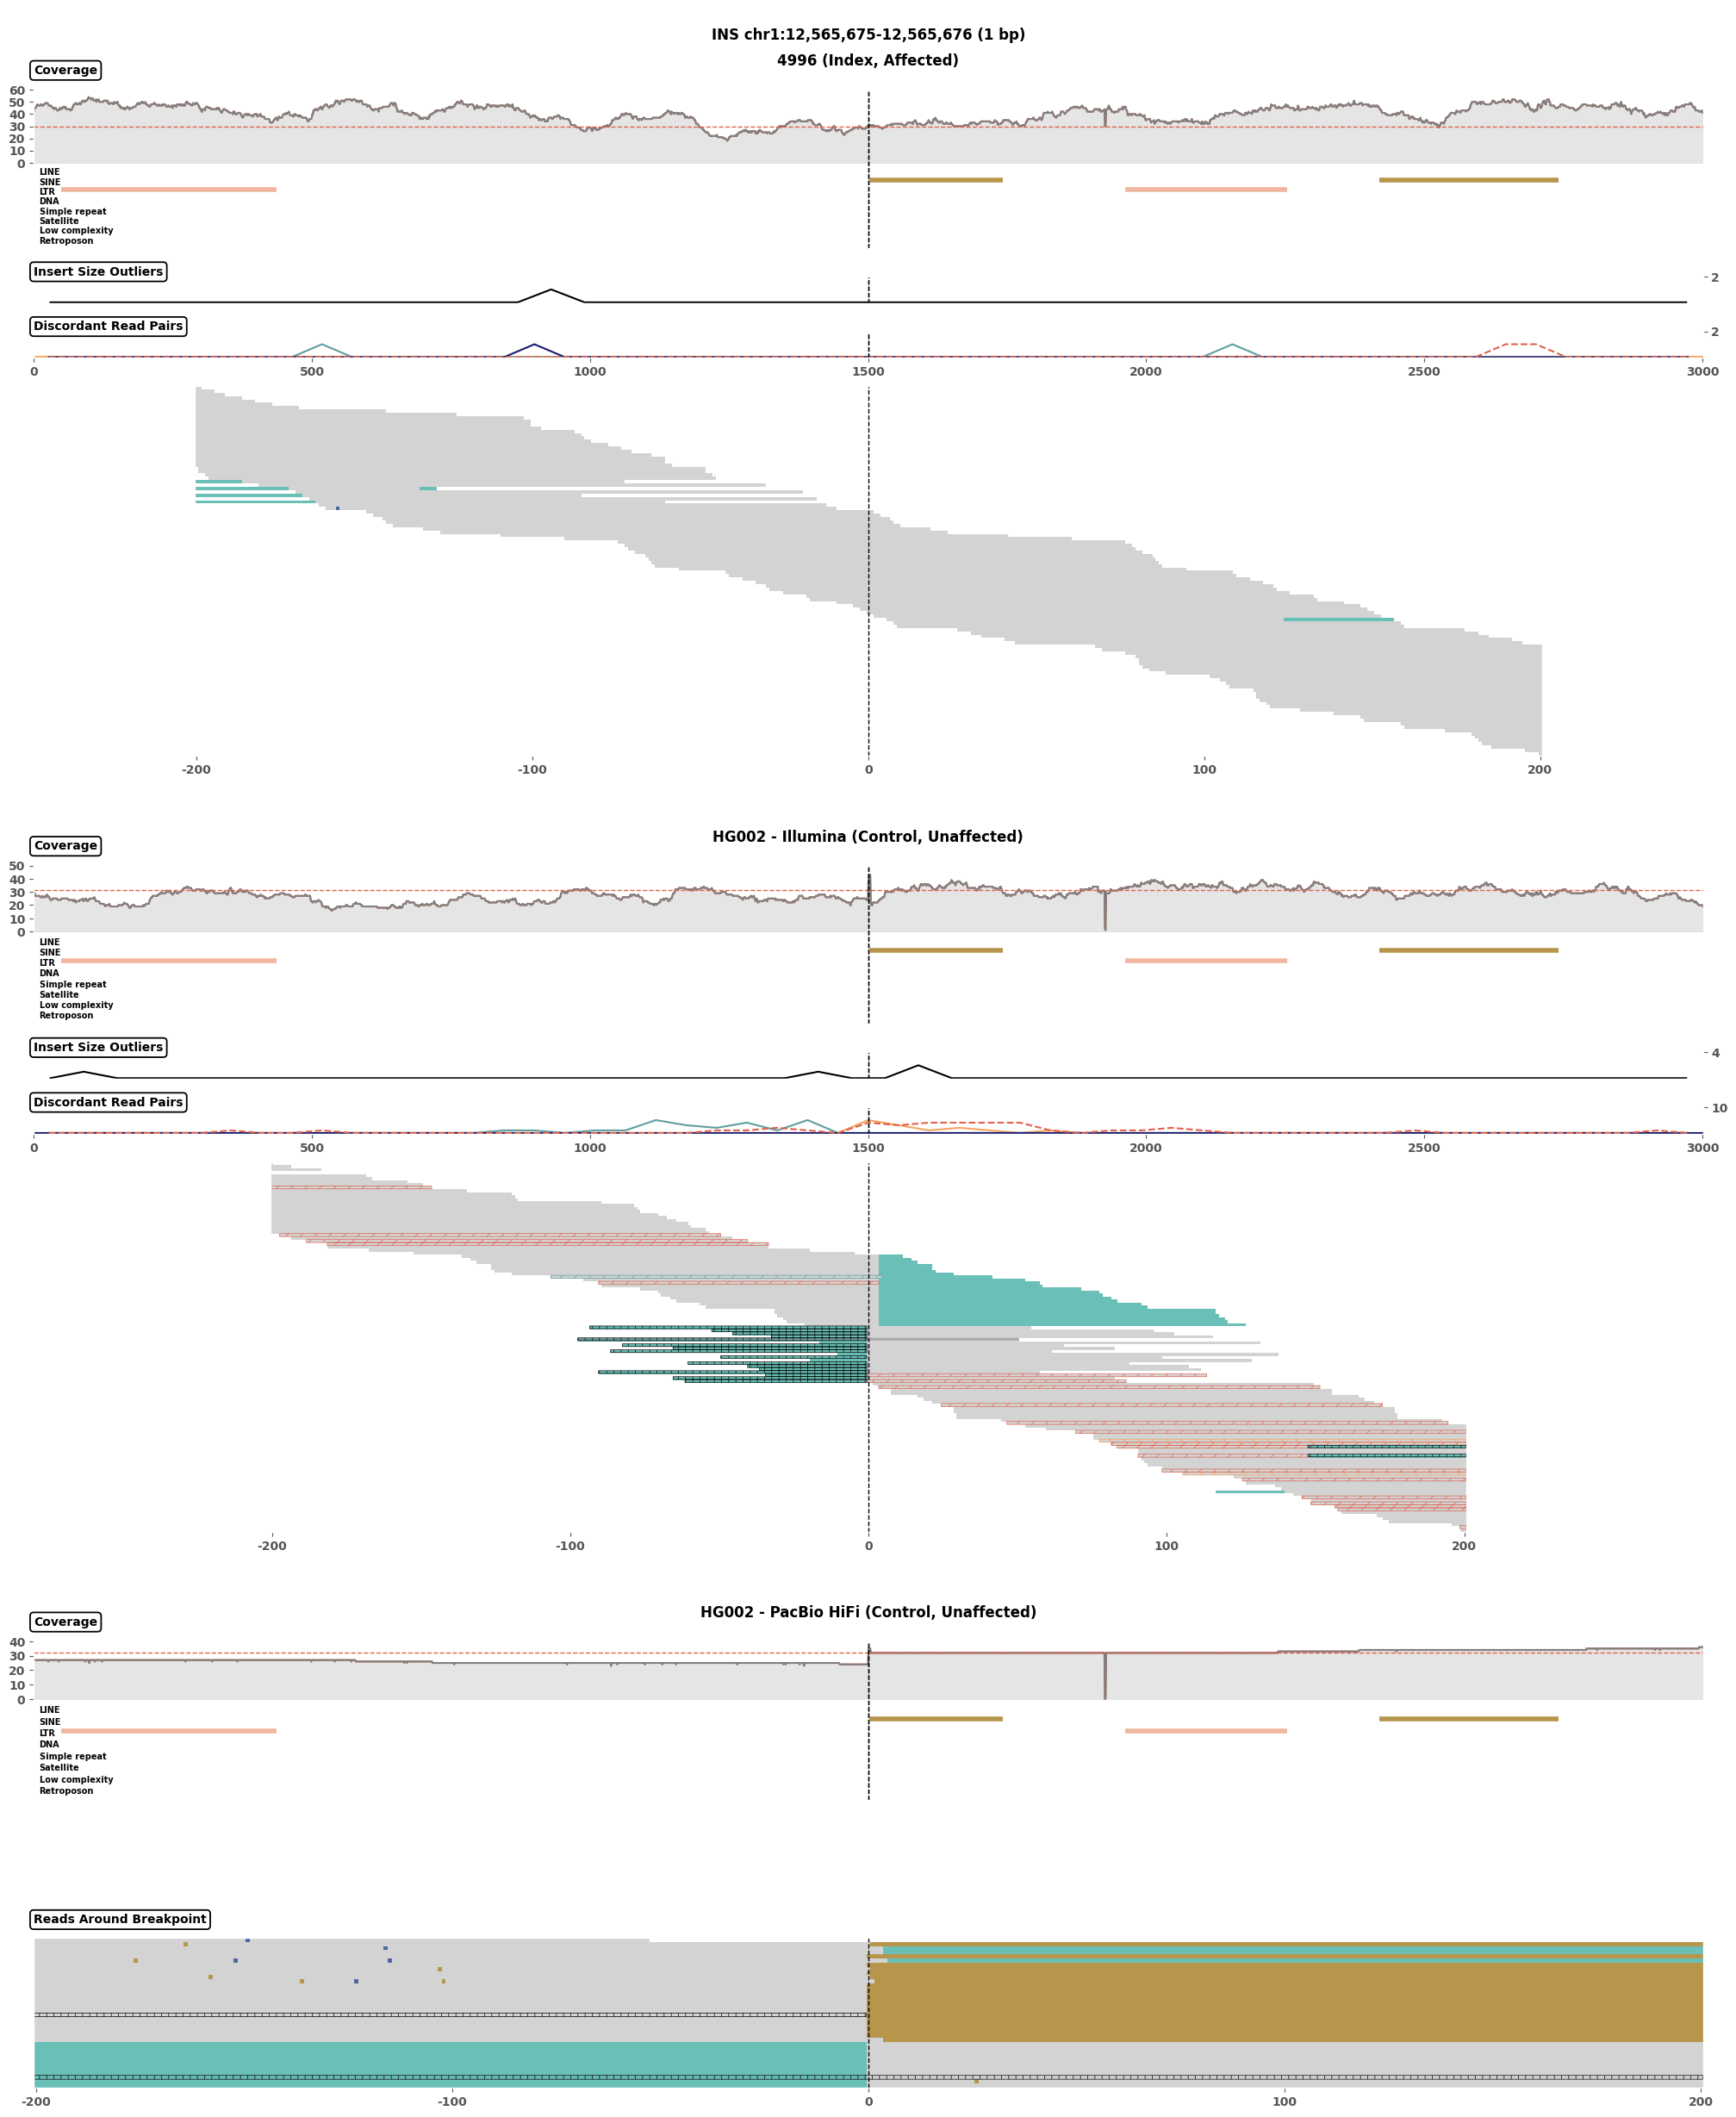

In [4]:
# Region
sv_type = 'INS'
chrom = 'chr1'
start = 12565675
stop = 12565676
sv_len = stop - start

# Samples from cohort
cohort_samples = {'4996' : {'family_status' : 'index',
                              'disease_status' : 'affected',
                              'technology' : 'ill',
                              'bam_name' : f'/confidential/typo/cohorts/limb2/aligned_bam/4996/GRCh38.bwa_mem.pe.sorted.mdup.recal.bam',
                              'baseline_cov' : 30}}

# Load baseline coverage for control samples
with open('resources/baseline_cov_ill.json', 'r') as f:
    baseline_cov_ill = json.load(f)
with open('resources/baseline_cov_pb.json', 'r') as f:
    baseline_cov_pb = json.load(f)

# Samples from control
control_samples = {'HG002 - Illumina' : {'family_status' : 'control',
                                         'disease_status' : 'unaffected',
                                         'technology' : 'ill',
                                         'bam_name' : '/confidential/FamilyR13/DATA/10x/SCRIPT/tGenVar/svdb/data/raw/1kg/hg38/HG002/ill/bam/GRCh38.bwa_mem.pe.sorted.mdup.recal.bam',
                                         'baseline_cov' : baseline_cov_ill[chrom]},
                   'HG002 - PacBio HiFi' : {'family_status' : 'control',
                                            'disease_status' : 'unaffected',
                                            'technology' : 'pb',
                                            'bam_name' : '/confidential/FamilyR13/DATA/10x/SCRIPT/tGenVar/svdb/data/raw/1kg/hg38/HG002/pb_hifi/bam/HG002_GRCh38.haplotag.10x.bam',
                                            'baseline_cov' : baseline_cov_pb[chrom]}}

samples = {**cohort_samples, **control_samples}

cuban(samples, repeat_df, sv_type, chrom, start, stop, padding=1500, window=200, collapse_ins=False, sv_len=sv_len)

# INV

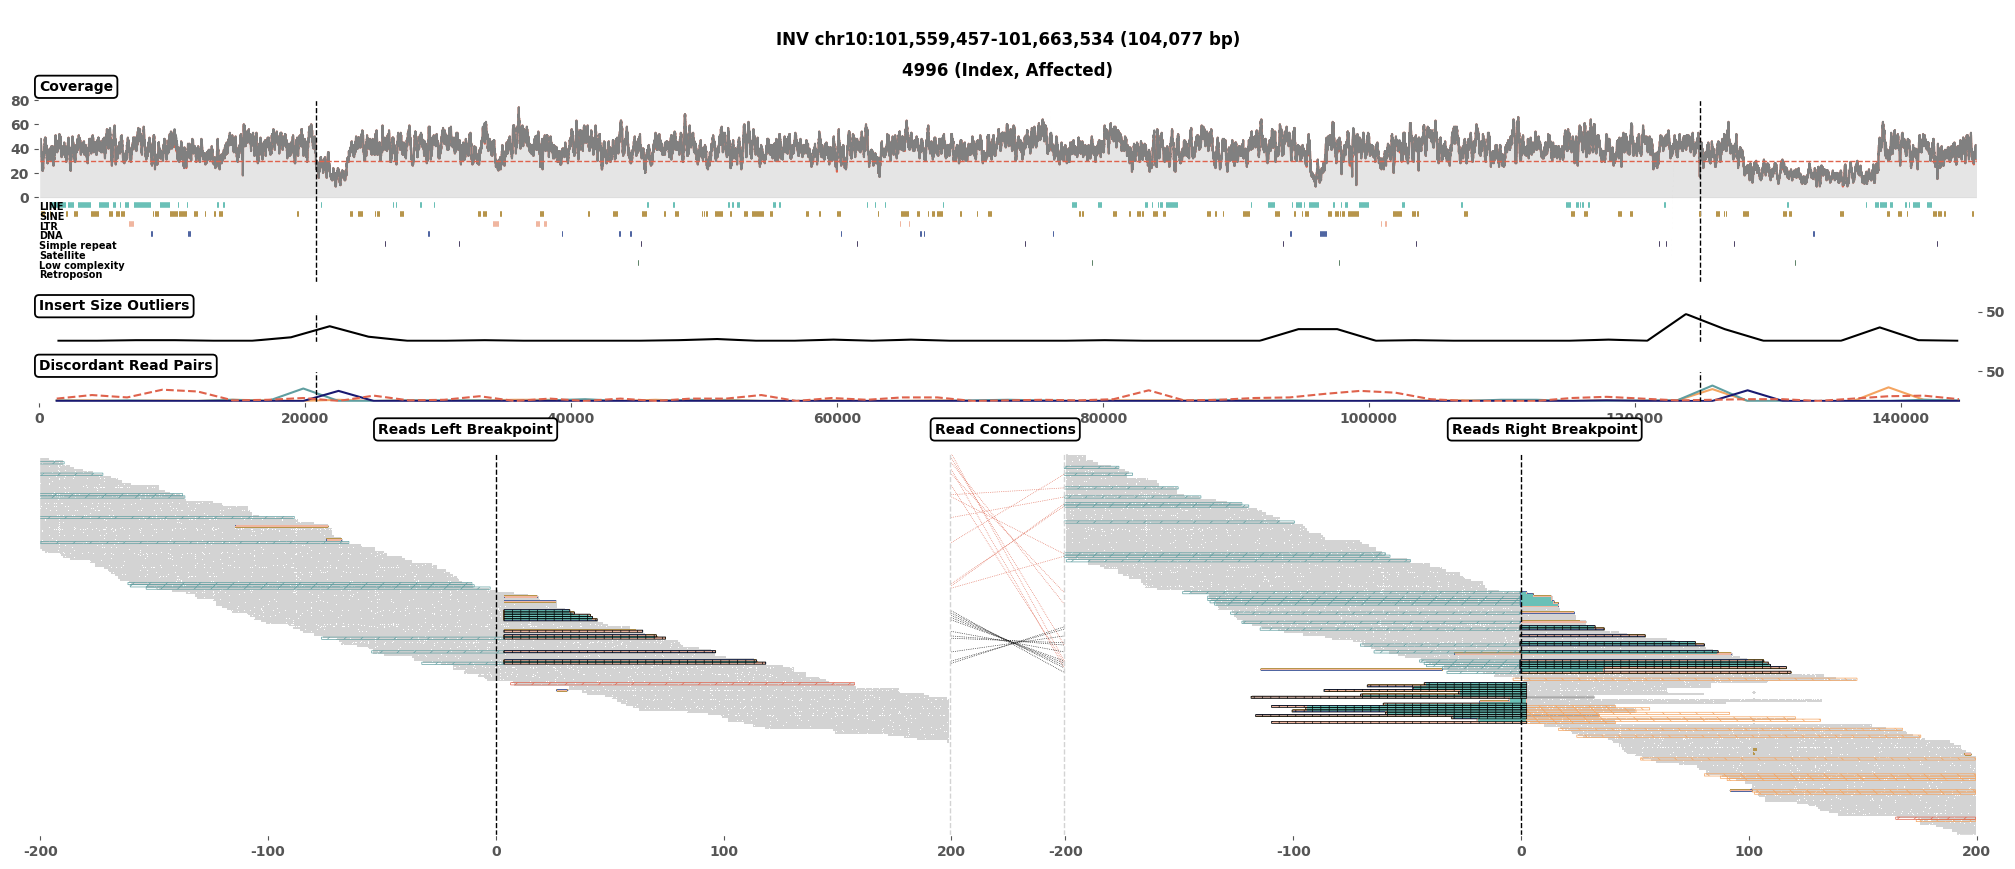

In [3]:
# Region
sv_type = 'INV'
chrom = 'chr10'
start = 101559457
stop = 101663534
sv_len = stop - start

# Samples from cohort
cohort_samples = {'4996' : {'family_status' : 'index',
                              'disease_status' : 'affected',
                              'technology' : 'ill',
                              'bam_name' : f'/confidential/typo/cohorts/limb2/aligned_bam/4996/GRCh38.bwa_mem.pe.sorted.mdup.recal.bam',
                              'baseline_cov' : 30}}

# Load baseline coverage for control samples
with open('resources/baseline_cov_ill.json', 'r') as f:
    baseline_cov_ill = json.load(f)
with open('resources/baseline_cov_pb.json', 'r') as f:
    baseline_cov_pb = json.load(f)

# Samples from control
control_samples = {'HG002 - Illumina' : {'family_status' : 'control',
                                         'disease_status' : 'unaffected',
                                         'technology' : 'ill',
                                         'bam_name' : '/confidential/FamilyR13/DATA/10x/SCRIPT/tGenVar/svdb/data/raw/1kg/hg38/HG002/ill/bam/GRCh38.bwa_mem.pe.sorted.mdup.recal.bam',
                                         'baseline_cov' : baseline_cov_ill[chrom]},
                   'HG002 - PacBio HiFi' : {'family_status' : 'control',
                                            'disease_status' : 'unaffected',
                                            'technology' : 'pb',
                                            'bam_name' : '/confidential/FamilyR13/DATA/10x/SCRIPT/tGenVar/svdb/data/raw/1kg/hg38/HG002/pb_hifi/bam/HG002_GRCh38.haplotag.10x.bam',
                                            'baseline_cov' : baseline_cov_pb[chrom]}}

samples = {**cohort_samples, **control_samples}

cuban(cohort_samples, repeat_df, sv_type, chrom, start, stop, padding=1500, window=200, collapse_ins=False, sv_len=sv_len)

# BND

(189, 207)
(189, 222)
(189, 223)
(189, 224)
(189, 229)
(189, 234)
(189, 240)
(189, 243)
(189, 244)
(189, 264)
(189, 265)
(189, 276)
(189, 278)
(189, 284)
(189, 290)
(189, 294)
(189, 296)
(189, 296)
(189, 304)
(189, 307)
(189, 308)
(155, 183)
(219, 305)
(118, 197)
(122, 197)
(272, 272)
(89, 197)
(107, 197)
(118, 197)
(159, 197)
(158, 197)
(133, 197)
(127, 197)
(127, 197)
(128, 197)
(99, 197)
(111, 197)
(122, 197)
(150, 198)
(155, 198)
(117, 198)
(136, 198)
(98, 198)
(98, 198)
(124, 198)
(124, 198)
(140, 198)
(115, 198)
(144, 199)
(87, 199)
(205, 237)
(205, 241)
(205, 249)
(205, 251)
(205, 259)
(205, 263)
(205, 266)
(205, 268)
(205, 270)
(205, 270)
(205, 274)
(205, 274)
(205, 275)
(205, 279)
(205, 280)
(205, 285)
(205, 287)
(205, 291)
(205, 294)
(205, 301)
(205, 306)
(205, 310)
(205, 311)
(157, 197)
(132, 197)
(107, 197)
(158, 197)
(127, 197)
(101, 197)
(161, 197)
(117, 197)
(115, 197)
(107, 197)
(140, 197)
(99, 197)
(159, 197)
(86, 197)
(150, 197)
(165, 197)
(131, 197)
(100, 197)
(146, 

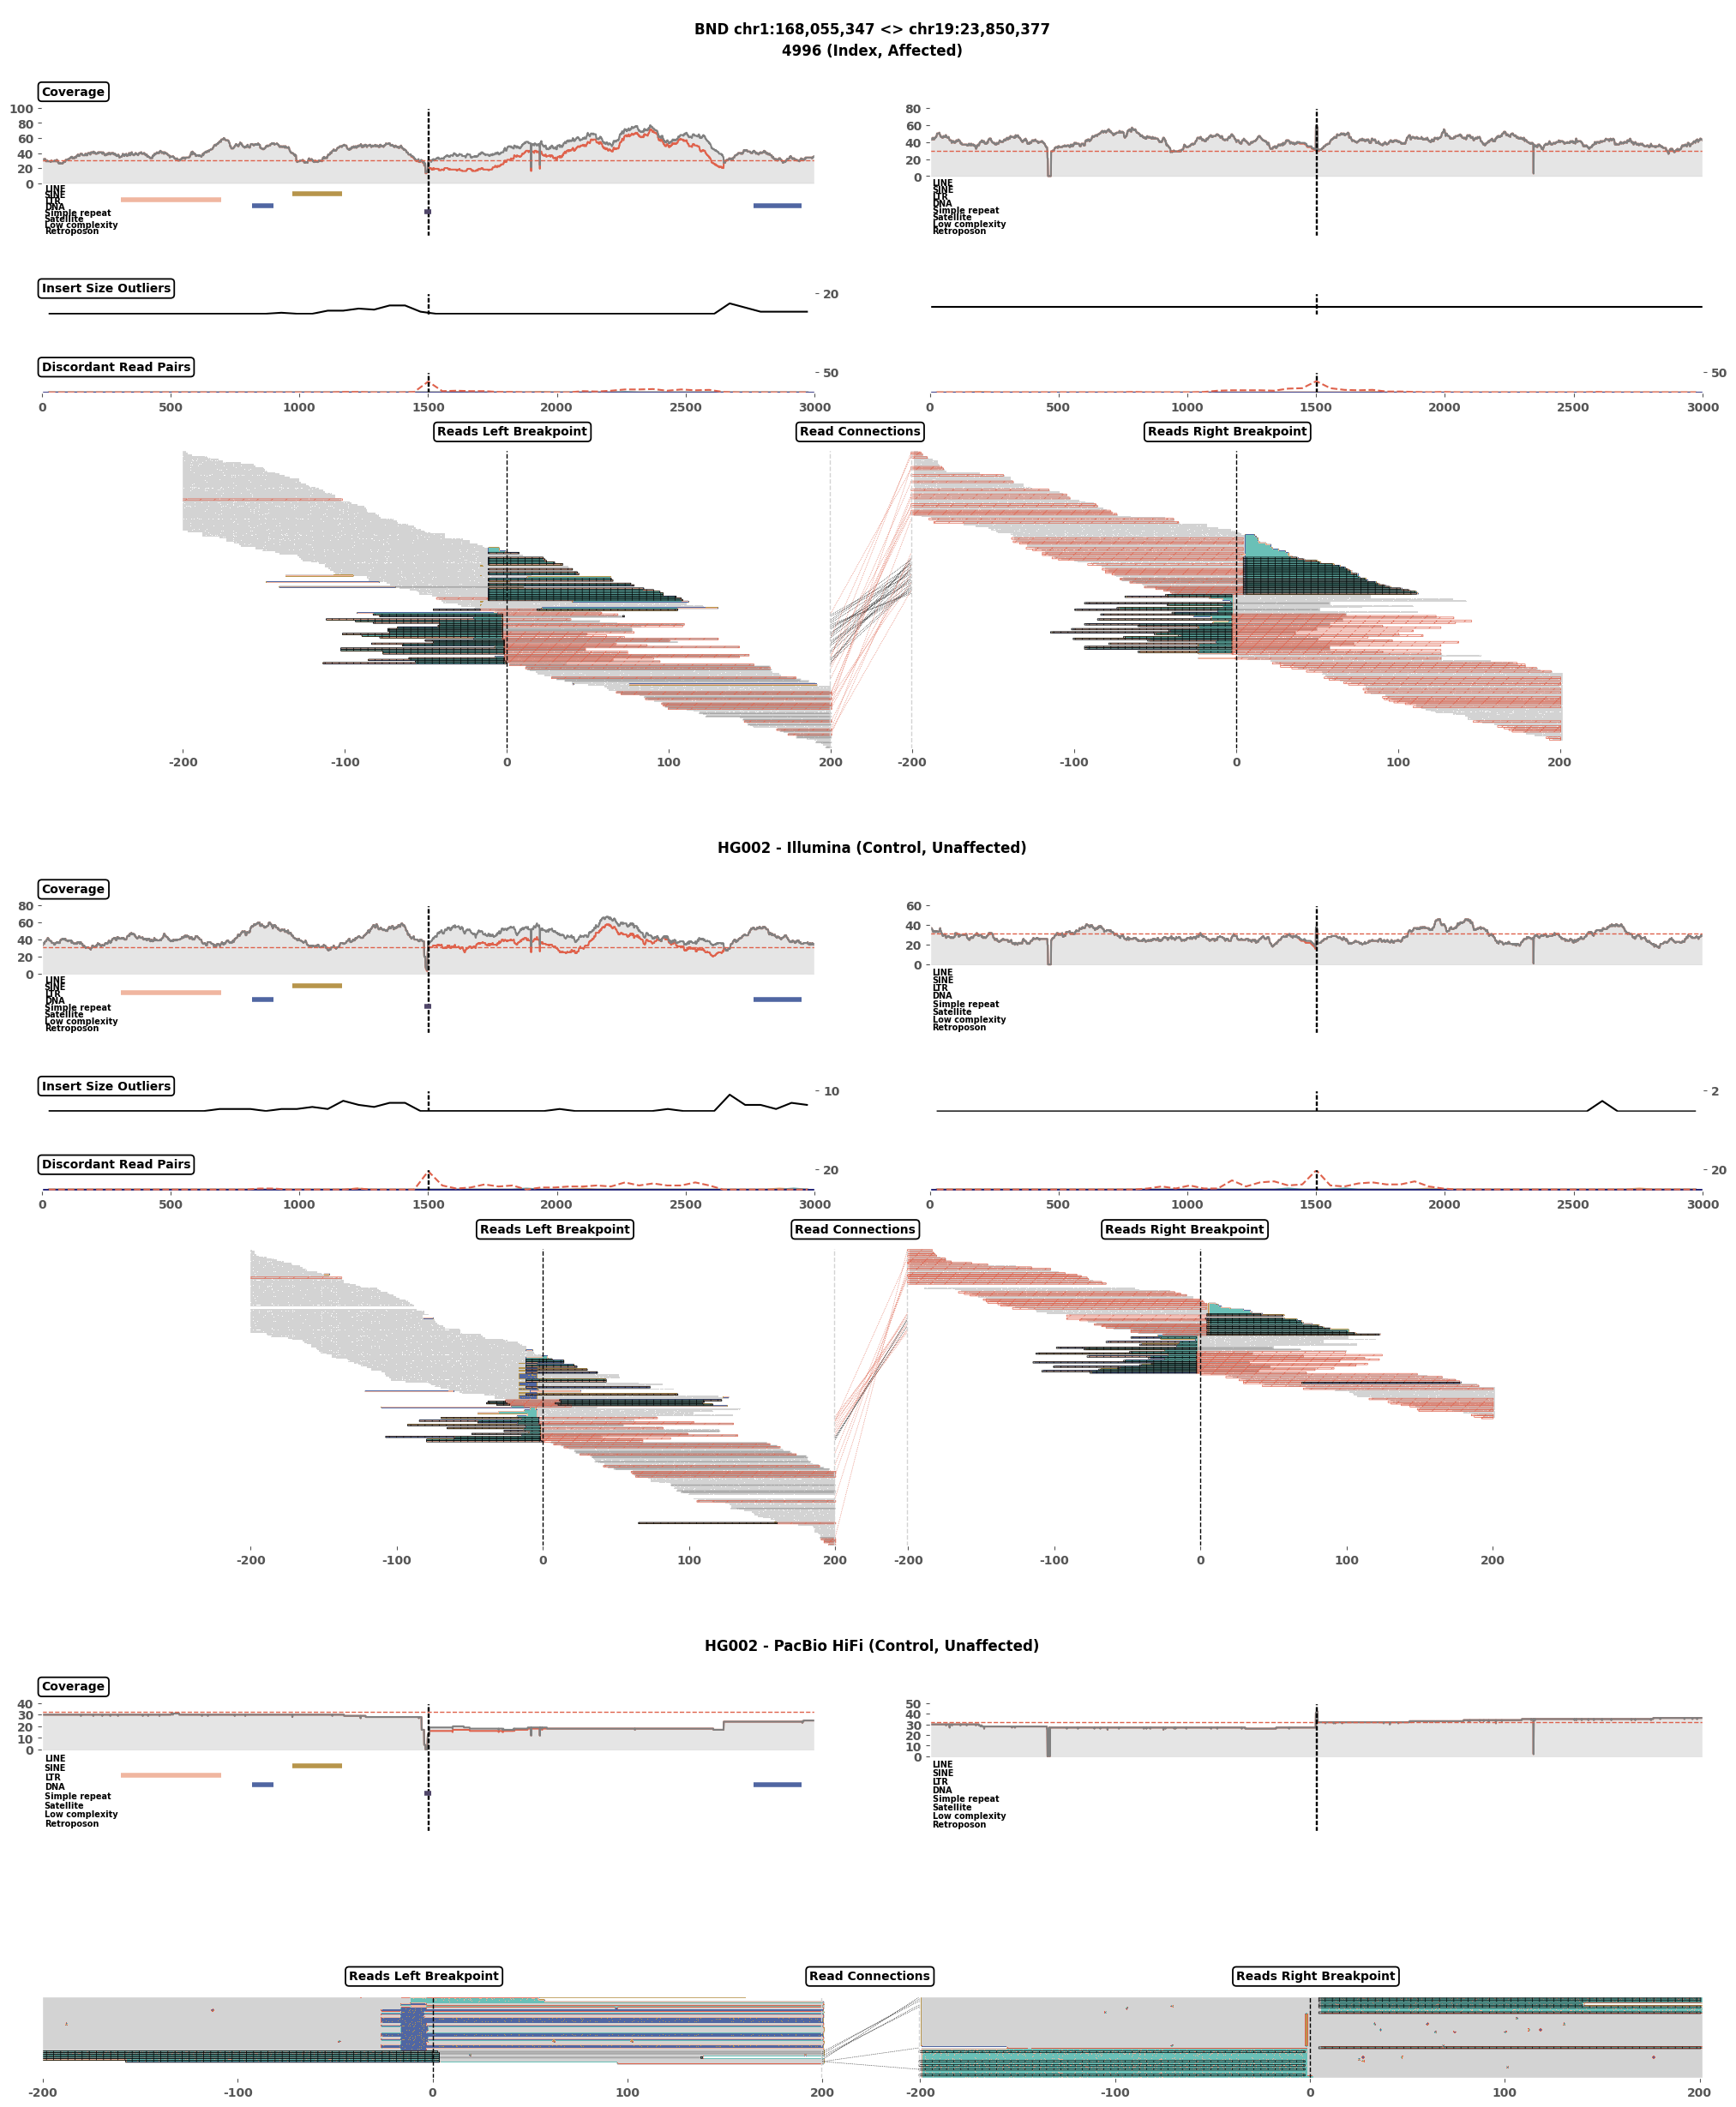

In [5]:
# Region
sv_type = 'BND'
chromA = 'chr1'
startA = 168055347
stopA = startA + 1
chromB = 'chr19'
startB = 23850377
stopB = startB + 1

# Samples from cohort
cohort_samples = {'4996' : {'family_status' : 'index',
                              'disease_status' : 'affected',
                              'technology' : 'ill',
                              'bam_name' : f'/confidential/typo/cohorts/limb2/aligned_bam/4996/GRCh38.bwa_mem.pe.sorted.mdup.recal.bam',
                              'baseline_cov' : 30}}

# Load baseline coverage for control samples
with open('resources/baseline_cov_ill.json', 'r') as f:
    baseline_cov_ill = json.load(f)
with open('resources/baseline_cov_pb.json', 'r') as f:
    baseline_cov_pb = json.load(f)

# Samples from control
control_samples = {'HG002 - Illumina' : {'family_status' : 'control',
                                         'disease_status' : 'unaffected',
                                         'technology' : 'ill',
                                         'bam_name' : '/confidential/FamilyR13/DATA/10x/SCRIPT/tGenVar/svdb/data/raw/1kg/hg38/HG002/ill/bam/GRCh38.bwa_mem.pe.sorted.mdup.recal.bam',
                                         'baseline_cov' : baseline_cov_ill[chromA]},
                   'HG002 - PacBio HiFi' : {'family_status' : 'control',
                                            'disease_status' : 'unaffected',
                                            'technology' : 'pb',
                                            'bam_name' : '/confidential/FamilyR13/DATA/10x/SCRIPT/tGenVar/svdb/data/raw/1kg/hg38/HG002/pb_hifi/bam/HG002_GRCh38.haplotag.10x.bam',
                                            'baseline_cov' : baseline_cov_pb[chromA]}}

samples = {**cohort_samples, **control_samples}

cuban_bnd(samples, repeat_df, chromA, startA, stopA, chromB, startB, stopB, padding=1500, window=200, collapse_ins=True)